In [26]:
print("Hello Gautami! My research environment works.")

Hello Gautami! My research environment works.


In [27]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [28]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [29]:
import pandas as pd

In [30]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [31]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

# Convert to pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [32]:
print("Dataset shape:", df.shape)

Dataset shape: (569, 31)


In [33]:
X = df.drop("target", axis=1)
y = df["target"]

print(X.head())
print(y.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (455, 30)
Testing size: (114, 30)


In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [36]:
predictions = model.predict(X_test)

print(predictions[:10])

[1 0 0 1 1 0 0 0 0 1]


In [37]:
predictions = model.predict(X_test)

print(predictions[:10])

[1 0 0 1 1 0 0 0 0 1]


In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

#Calculate Accuracy

Model Accuracy: 0.9649122807017544


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

#shows confusion matrix to analyze predictions

[[40  3]
 [ 1 70]]


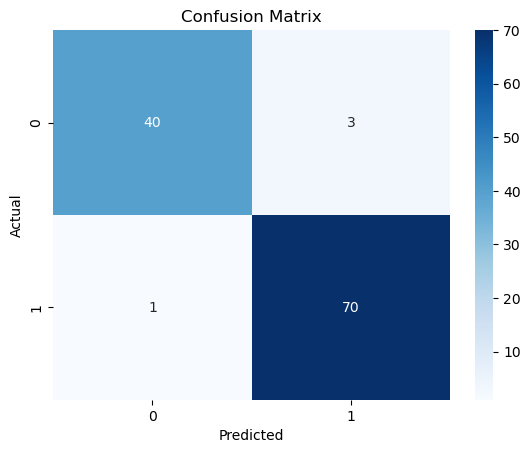

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#visulization of Confusion Matrix 
#40 correct negatives
#70 correct positives
#3 false positives
#1 false negative

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

#calculated Accuracy, Precision, Recall, F1 score

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [42]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10)

#You will see the top 10 most important features.

mean concave points     0.132583
worst concave points    0.117387
worst perimeter         0.112833
worst area              0.102656
worst radius            0.078237
mean perimeter          0.053265
mean area               0.050354
worst concavity         0.045291
mean concavity          0.039767
area error              0.038915
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

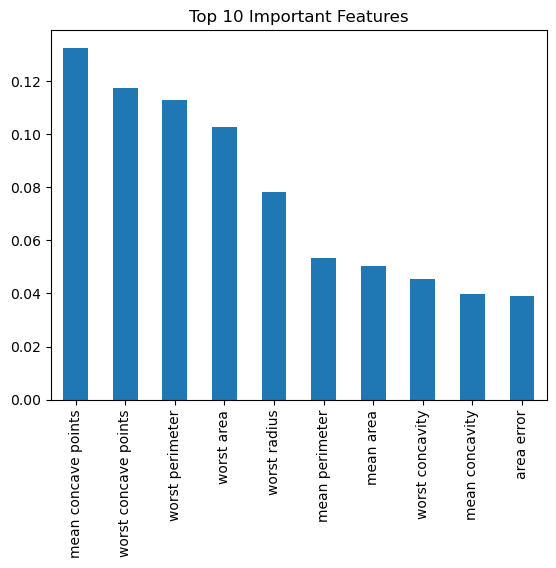

In [43]:
feature_importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.show

#graph of top 10 most important features.

In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

#We’ll compare: Logistic Regression (baseline),    Random Forest (strong),  SVM (also strong)

Train: (455, 30) Test: (114, 30)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel="rbf")
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

#Train & evaluate 3 models
#This is my performance comparison table.

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.964912,0.959459,0.986111,0.972603
1,Random Forest,0.956140,0.958904,0.972222,0.965517
2,SVM,0.929825,0.921053,0.972222,0.945946


In [49]:
results_df_rounded = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_df_rounded[col] = results_df_rounded[col].round(3)

results_df_rounded
#clean performance comparison table - Round values (looks professional)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.965,0.959,0.986,0.973
1,Random Forest,0.956,0.959,0.972,0.966
2,SVM,0.930,0.921,0.972,0.946


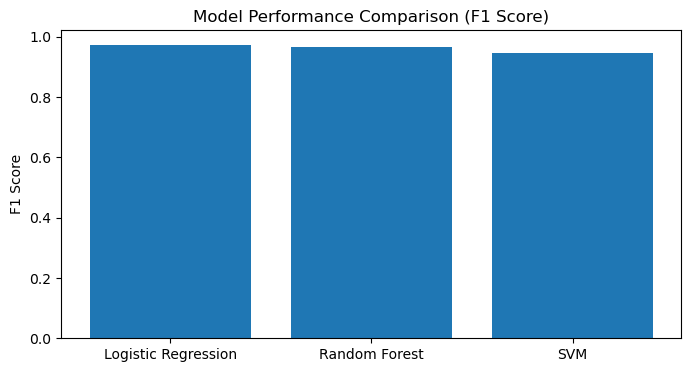

In [50]:
plt.figure(figsize=(8,4))

plt.bar(results_df["Model"], results_df["F1 Score"])

plt.title("Model Performance Comparison (F1 Score)")
plt.ylabel("F1 Score")

plt.show()

#bar chart comparing F1 scores

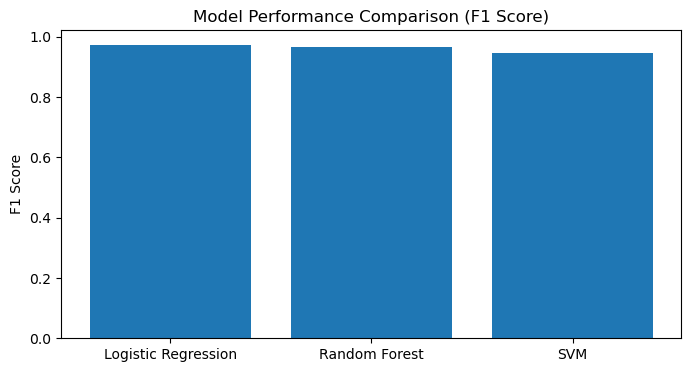

In [23]:
plt.figure(figsize=(8,4))

plt.bar(results_df["Model"], results_df["F1 Score"])

plt.title("Model Performance Comparison (F1 Score)")
plt.ylabel("F1 Score")

plt.savefig("model_comparison.png")

plt.show()

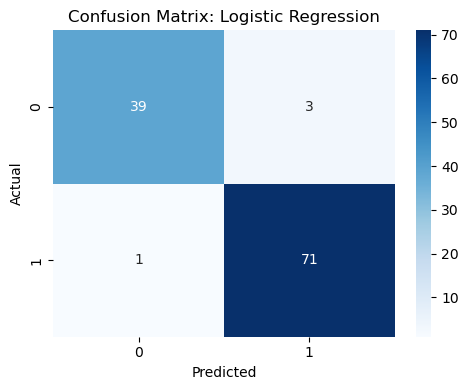

Best model: Logistic Regression


In [51]:
best_model_name = results_df.iloc[0]["Model"]
best_clf = models[best_model_name]

best_preds = best_clf.predict(X_test)
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Best model:", best_model_name)

#confusion matrix for the best model: Logistic Regression

In [52]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("Best Model:")
print(best_model)

#highlight the best model

Best Model:
Model        Logistic Regression
Accuracy                0.964912
Precision               0.959459
Recall                  0.986111
F1 Score                0.972603
Name: 0, dtype: object
